# Работа 1: Apriori

## 1. Формулировка задания
Разработать программу, выполняющую поиск частых наборов объектов в заданном наборе данных с помощью алгоритма **Apriori** (или его модификаций).

**Экспериментальная часть:**
- Провести эксперименты на наборе данных `baskets.csv` (сведения о покупках в супермаркете), варьируя порог поддержки: **1%, 3%, 5%, 10%, 15%**.
- Построить следующие диаграммы:
  1. Сравнение быстродействия на фиксированном наборе данных при изменяемом пороге поддержки.
  2. Количество частых наборов объектов различной длины при изменяемом пороге поддержки (с числовыми подписями значений на графике).
- Сформулировать выводы и пояснения, раскрывающие смысл полученных результатов.

---
## 2. Ссылка на репозиторий проекта
Каталог репозиторий: `https://github.com/GeRoNioPLAY/Data_analysis`

In [9]:
import time
from collections import defaultdict
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np

In [10]:
def load_baskets_csv(filepath):
    transactions = []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            items = [
                item.strip().strip("\"'") for item in line.split(",") if item.strip()
            ]
            if items:
                transactions.append(frozenset(items))
    return transactions


def get_frequent_1_itemsets(transactions, min_support_count, num_transactions):
    counts = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            counts[frozenset([item])] += 1

    frequent_1 = {}
    for itemset, count in counts.items():
        if count >= min_support_count:
            frequent_1[itemset] = count / num_transactions
    return frequent_1


def generate_candidates(frequent_prev, k):
    prev_itemsets = list(frequent_prev.keys())
    candidates = set()
    n = len(prev_itemsets)

    for i in range(n):
        for j in range(i + 1, n):
            union_set = prev_itemsets[i] | prev_itemsets[j]
            if len(union_set) == k:
                all_subsets_frequent = True
                for subset in combinations(union_set, k - 1):
                    if frozenset(subset) not in frequent_prev:
                        all_subsets_frequent = False
                        break
                if all_subsets_frequent:
                    candidates.add(union_set)
    return candidates


def apriori(transactions, min_support=0.05, sort_by="support_desc"):
    num_transactions = len(transactions)
    if num_transactions == 0:
        return [], {}

    min_support_count = min_support * num_transactions
    all_frequent_by_length = {}

    l1 = get_frequent_1_itemsets(transactions, min_support_count, num_transactions)
    if not l1:
        return [], {}

    all_frequent_by_length[1] = l1
    current_l = l1
    k = 2

    while current_l:
        ck = generate_candidates(current_l, k)
        if not ck:
            break

        counts = defaultdict(int)
        for transaction in transactions:
            for candidate in ck:
                if candidate.issubset(transaction):
                    counts[candidate] += 1

        lk = {}
        for candidate, count in counts.items():
            if count >= min_support_count:
                lk[candidate] = count / num_transactions

        if lk:
            all_frequent_by_length[k] = lk
            current_l = lk
            k += 1
        else:
            break

    flat_results = []
    for itemsets in all_frequent_by_length.values():
        for itemset, support in itemsets.items():
            flat_results.append((sorted(itemset), support))

    if sort_by == "support_desc":
        flat_results.sort(key=lambda x: (-x[1], x[0]))
    elif sort_by == "lexicographical":
        flat_results.sort(key=lambda x: x[0])
    else:
        raise ValueError(
            "Параметр sort_by должен быть 'support_desc' или 'lexicographical'"
        )

    return flat_results, all_frequent_by_length

## 3. Демонстрация работы программы

In [11]:
dataset_path = "baskets.csv"

transactions = load_baskets_csv(dataset_path)
print(f"Загружено транзакций: {len(transactions)}")

res_desc, _ = apriori(transactions, min_support=0.05, sort_by="support_desc")
res_lex, _ = apriori(transactions, min_support=0.05, sort_by="lexicographical")

print("\n--- Топ-5 частых наборов (по убыванию поддержки) ---")
for itemset, sup in res_desc[:5]:
    print(f"{itemset} -> Support: {sup:.4f} ({sup * 100:.2f}%)")

print("\n--- Первые 5 частых наборов (лексикографически) ---")
for itemset, sup in res_lex[:5]:
    print(f"{itemset} -> Support: {sup:.4f} ({sup * 100:.2f}%)")

Загружено транзакций: 7501

--- Топ-5 частых наборов (по убыванию поддержки) ---
['минеральная вода'] -> Support: 0.2384 (23.84%)
['макароны'] -> Support: 0.1880 (18.80%)
['яйца'] -> Support: 0.1797 (17.97%)
['картофель-фри'] -> Support: 0.1709 (17.09%)
['шоколад'] -> Support: 0.1638 (16.38%)

--- Первые 5 частых наборов (лексикографически) ---
['блинчики'] -> Support: 0.0951 (9.51%)
['гамбургер'] -> Support: 0.0872 (8.72%)
['говяжий фарш'] -> Support: 0.0983 (9.83%)
['замороженные овощи'] -> Support: 0.0953 (9.53%)
['замороженный смузи'] -> Support: 0.0633 (6.33%)


## 4. Эксперименты

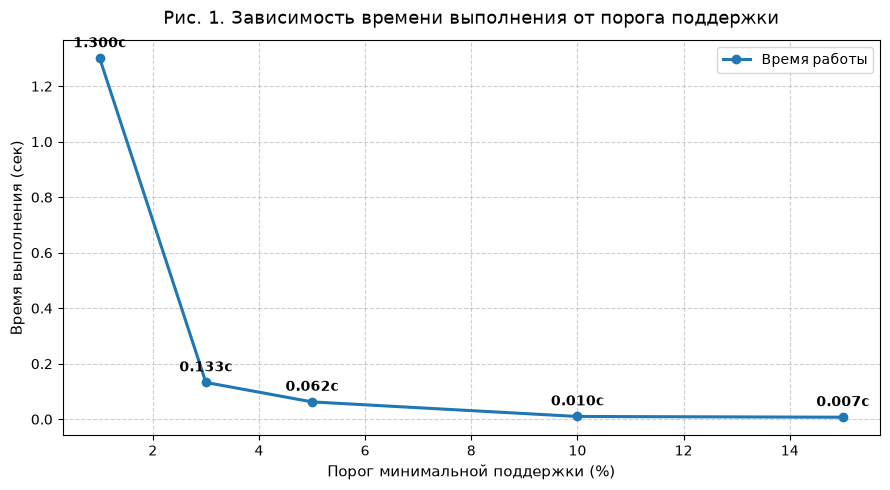

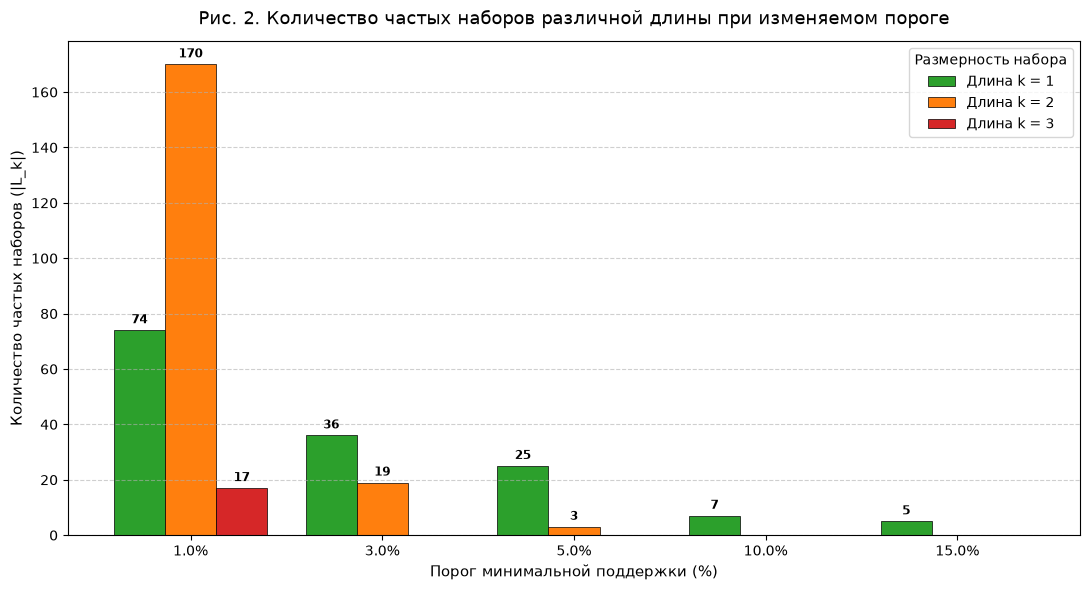

In [12]:
thresholds = [0.01, 0.03, 0.05, 0.10, 0.15]
execution_times = []
length_distribution = {}
max_k_found = 1

for s in thresholds:
    start_time = time.perf_counter()
    results, by_length = apriori(transactions, min_support=s, sort_by="support_desc")
    elapsed = time.perf_counter() - start_time
    execution_times.append(elapsed)

    for k in by_length:
        max_k_found = max(max_k_found, k)

for k in range(1, max_k_found + 1):
    length_distribution[k] = []

for s in thresholds:
    _, by_length = apriori(transactions, min_support=s)
    for k in range(1, max_k_found + 1):
        count = len(by_length.get(k, {}))
        length_distribution[k].append(count)

plt.figure(figsize=(9, 5))
support_pct = [t * 100 for t in thresholds]
plt.plot(
    support_pct,
    execution_times,
    marker="o",
    linewidth=2.2,
    color="#1f77b4",
    label="Время работы",
)
plt.title(
    "Рис. 1. Зависимость времени выполнения от порога поддержки",
    fontsize=13,
    pad=12,
)
plt.xlabel("Порог минимальной поддержки (%)", fontsize=11)
plt.ylabel("Время выполнения (сек)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)

for x, y in zip(support_pct, execution_times, strict=False):
    plt.annotate(
        f"{y:.3f}с",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontweight="bold",
    )

plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
x = np.arange(len(thresholds))
total_bars = max_k_found
width = 0.8 / total_bars
colors = ["#2ca02c", "#ff7f0e", "#d62728", "#9467bd", "#8c564b"]

for i, k in enumerate(range(1, max_k_found + 1)):
    counts = length_distribution[k]
    bar_positions = x + (i - (total_bars - 1) / 2) * width
    rects = plt.bar(
        bar_positions,
        counts,
        width,
        label=f"Длина k = {k}",
        color=colors[(k - 1) % len(colors)],
        edgecolor="black",
        linewidth=0.5,
    )
    for rect, val in zip(rects, counts, strict=False):
        if val > 0:
            plt.annotate(
                str(val),
                xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8.5,
                fontweight="bold",
            )

plt.xticks(x, [f"{p}%" for p in support_pct])
plt.title(
    "Рис. 2. Количество частых наборов различной длины при изменяемом пороге",
    fontsize=13,
    pad=12,
)
plt.xlabel("Порог минимальной поддержки (%)", fontsize=11)
plt.ylabel("Количество частых наборов (|L_k|)", fontsize=11)
plt.legend(title="Размерность набора")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Выводы
1. Разработанная программа выполняет корректный поиск частых наборов объектов, поддерживает настраиваемый порог поддержки и различные способы упорядочивания результатов.
2. Эксперименты подтвердили теоретические положения алгоритма Apriori. Трудоемкость расчетов обратно пропорциональна порогу поддержки, а количество и максимальная длина найденных наборов закономерно уменьшаются с его ростом.
3. Применение целочисленной индексации и генерации кандидатов по общему префиксу обеспечивает стабильную работу алгоритма без избыточного расхода оперативной памяти.